In [146]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [147]:
house_prices = pd.read_csv('../datasets/house_prices_cleaned.zip')
house_copy = house_prices.copy()
house_copy.drop('Unnamed: 0', axis= 'columns', inplace= True)

C:\Users\HP\AppData\Local\Temp\ipykernel_15084\1314455057.py:1: DtypeWarning: Columns (0: locality) have mixed types. Specify dtype option on import or set low_memory=False.
  house_prices = pd.read_csv('../datasets/house_prices_cleaned.zip')


In [148]:
house_copy.describe()

,amount,price,carpet_area,bathroom,balcony,car_parking,super_area,bedrooms,total_floors
count,67841.000000,6.357500e+04,3.807500e+04,67721.000000,49133.000000,28863.000000,6.375800e+04,67831.000000,65529.000000
mean,107.353995,6.669812e+03,3.052560e+03,2.411187,2.087049,4.024045,3.215058e+03,2.543483,8.521281
std,687.905116,4.410867e+04,3.349072e+05,0.899991,1.019998,34.227493,2.399354e+05,0.831290,6.964287
min,1.000000,0.000000e+00,1.000000e+00,1.000000,1.000000,1.000000,1.000000e+00,1.000000,1.000000
25%,40.000000,3.765000e+03,8.010000e+02,2.000000,1.000000,1.000000,9.950249e+02,2.000000,4.000000
50%,64.000000,5.000000e+03,1.100000e+03,2.000000,2.000000,1.000000,1.287895e+03,3.000000,5.000000
75%,106.000000,7.034000e+03,1.476000e+03,3.000000,3.000000,1.000000,1.730000e+03,3.000000,12.000000
max,140030.000000,6.700000e+06,6.534000e+07,11.000000,11.000000,999.000000,4.347288e+07,10.000000,200.000000


# Univariate Analysis

In [149]:
def pie(df, explode, colors, edgecolor, textcolor):
    wedges, texts, autotexts = plt.pie(x= df.values, labels= df.index, explode= explode, autopct= '%0.1f%%', colors= colors, shadow= True)
    for wedge in wedges:
        wedge.set_edgecolor(edgecolor)

    for text in texts:
        text.set_fontweight('bold')

    for autotext in autotexts:
        autotext.set_fontweight('bold')
        autotext.set_color(textcolor)

In [150]:
def uni_box(y):
    sns.catplot(data= house_copy, y= y, kind= 'box')

In [151]:
def uni_hist(x, color):
    sns.displot(data= house_copy, x= x, kind= 'hist', kde= True, color= color)
    plt.xlim(house_copy[x].quantile(0.01), house_copy[x].quantile(0.99))

In [152]:
def bar_h(df, y, threshold, palette, edgecolor, linewidth):
    df = df[df['count'] >= threshold]
    sns.barplot(data= df, x= 'count', y= y, hue= y, palette= palette, edgecolor= edgecolor, linewidth= linewidth)

In [153]:
def bar_v(df, palette, edgecolor, linewidth):
    sns.catplot(x= df.index, y= df.values, kind= 'bar', palette= palette, edgecolor= edgecolor, linewidth= linewidth)

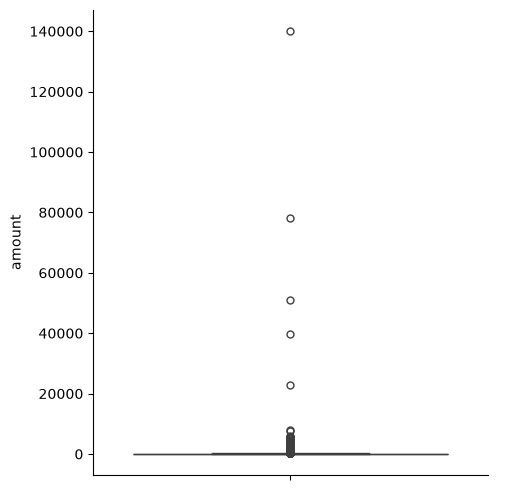

In [154]:
uni_box('amount')

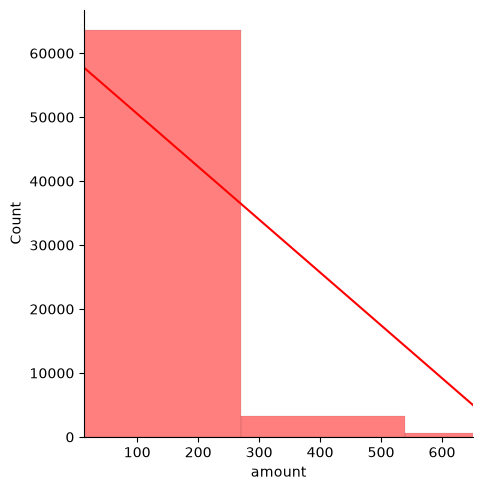

In [155]:
uni_hist('amount', 'red')

In [156]:
house_copy['amount'].skew()

np.float64(154.94097382310096)

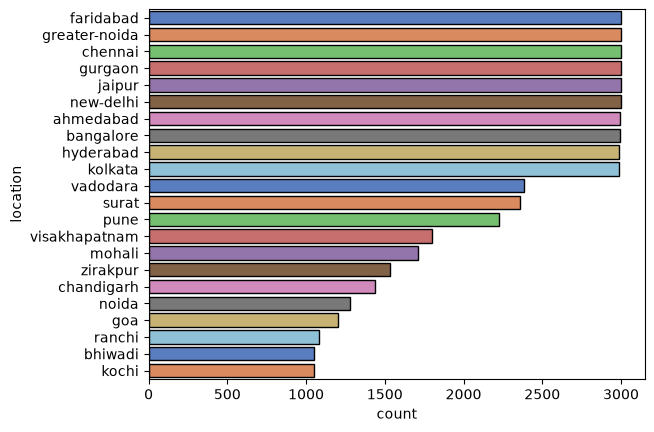

In [157]:
location_count = house_copy['location'].value_counts().reset_index()
bar_h(location_count, 'location', 1000, 'muted', 'black', 1)

In [158]:
location_count[location_count['count'] >= 1000]['count'].sum() / len(house_copy)

np.float64(0.7194832238385734)

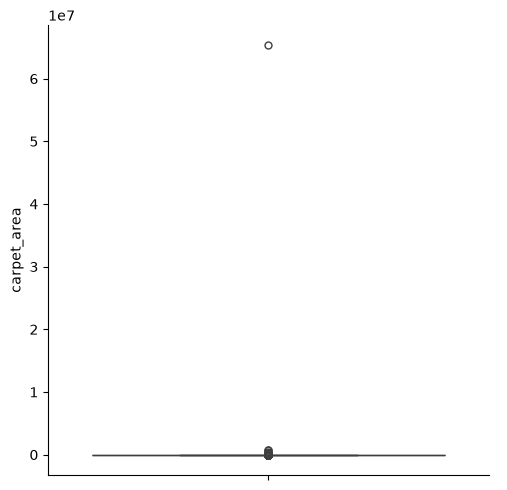

In [159]:
uni_box('carpet_area')

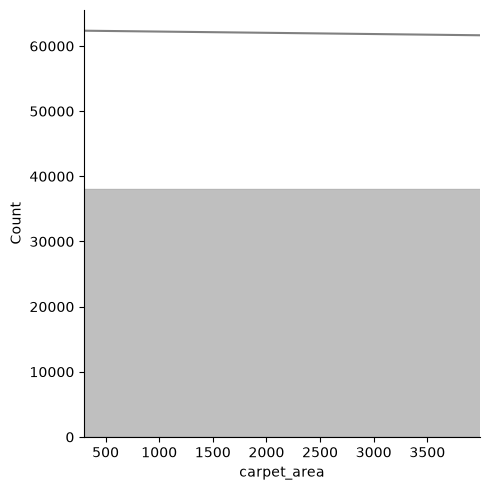

In [160]:
uni_hist('carpet_area', 'grey')

In [161]:
house_copy['carpet_area'].skew()

np.float64(195.0287137011458)

C:\Users\HP\AppData\Local\Temp\ipykernel_15084\2590324310.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x= df.index, y= df.values, kind= 'bar', palette= palette, edgecolor= edgecolor, linewidth= linewidth)


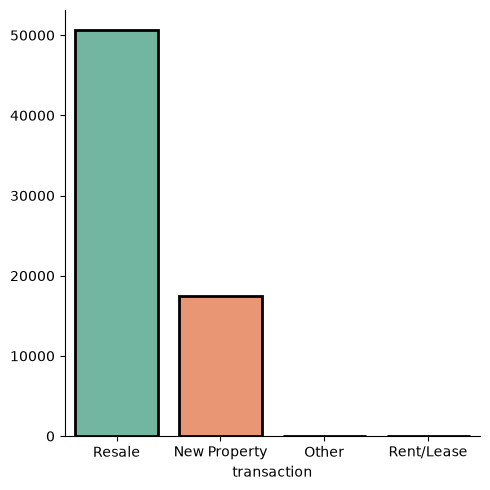

In [162]:
transaction_count = house_copy['transaction'].value_counts()
bar_v(transaction_count, 'Set2', 'black', 2)

In [163]:
transaction_count = transaction_count.reset_index()
transaction_count['percent'] = (transaction_count['count'] / sum(transaction_count['count'])) * 100
transaction_count

,transaction,count,percent
0,Resale,50614,74.307778
1,New Property,17438,25.601198
2,Other,60,0.088088
3,Rent/Lease,2,0.002936


In [164]:
house_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 68192 entries, 0 to 68191
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               68192 non-null  str    
 1   description         65974 non-null  str    
 2   amount              67841 non-null  float64
 3   price               63575 non-null  float64
 4   location            68192 non-null  str    
 5   carpet_area         38075 non-null  float64
 6   floor               65577 non-null  str    
 7   transaction         68114 non-null  str    
 8   furnishing          68192 non-null  str    
 9   facing              41392 non-null  str    
 10  overlooking         38657 non-null  str    
 11  society             29372 non-null  str    
 12  bathroom            67721 non-null  float64
 13  balcony             49133 non-null  float64
 14  car_parking         28863 non-null  float64
 15  ownership           43264 non-null  str    
 16  super_area     

C:\Users\HP\AppData\Local\Temp\ipykernel_15084\2590324310.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x= df.index, y= df.values, kind= 'bar', palette= palette, edgecolor= edgecolor, linewidth= linewidth)


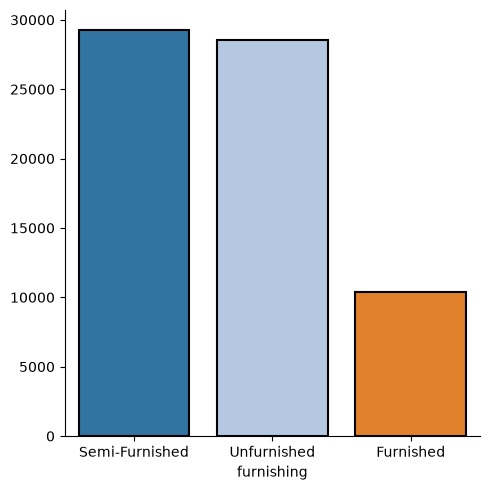

In [165]:
furnish_count = house_copy['furnishing'].value_counts()
bar_v(furnish_count, 'tab20', 'black', 1.5)

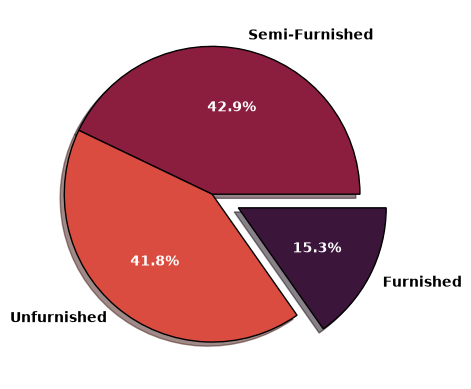

In [166]:
pie(furnish_count, [0, 0, 0.2], ['#8b1e3f', '#db4c40', '#3c153b'], 'black', 'white')



In [167]:
house_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 68192 entries, 0 to 68191
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               68192 non-null  str    
 1   description         65974 non-null  str    
 2   amount              67841 non-null  float64
 3   price               63575 non-null  float64
 4   location            68192 non-null  str    
 5   carpet_area         38075 non-null  float64
 6   floor               65577 non-null  str    
 7   transaction         68114 non-null  str    
 8   furnishing          68192 non-null  str    
 9   facing              41392 non-null  str    
 10  overlooking         38657 non-null  str    
 11  society             29372 non-null  str    
 12  bathroom            67721 non-null  float64
 13  balcony             49133 non-null  float64
 14  car_parking         28863 non-null  float64
 15  ownership           43264 non-null  str    
 16  super_area     